# D2C Customer Churn Prediction Model
## Part 3: Churn Prediction Model & Model Card

**Objective:** Build a churn-prediction model that identifies customers likely to churn in the next 60 days.

**Snapshot Date:** 2025-09-30  
**Target Window:** 60 days (2025-10-01 to 2025-11-29)  
**Leakage Rule:** Use ONLY data available on or before 2025-09-30

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score, precision_score, 
    recall_score, accuracy_score
)
import xgboost as xgb
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries loaded successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"Scikit-learn: Available")

Libraries loaded successfully!
XGBoost version: 2.0.1
Scikit-learn: Available


## Section 1: Load Data from Modeling Snapshot

The `rfm_modeling_snapshot.csv` contains pre-engineered features ready for modeling.  
These features were calculated using only data available on or before 2025-09-30 (no leakage).

In [22]:
# Load the modeling snapshot
data_path = 'data/rfm_modeling_snapshot.csv'
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"\nFirst few rows:")
print(df.head(10))

Dataset shape: (2400, 29)
Rows: 2400, Columns: 29

First few rows:
  customer_id snapshot_date city_tier age_group acquisition_channel  \
0   CUST00001    2025-09-30    Tier 1     18-24           Instagram   
1   CUST00002    2025-09-30    Tier 2     25-34         Marketplace   
2   CUST00003    2025-09-30    Tier 1     25-34          Influencer   
3   CUST00004    2025-09-30    Tier 3     25-34       Google Search   
4   CUST00005    2025-09-30    Tier 3     35-44             Organic   
5   CUST00006    2025-09-30    Tier 2     35-44           Instagram   
6   CUST00007    2025-09-30    Tier 1     18-24             Organic   
7   CUST00008    2025-09-30    Tier 2     18-24             Organic   
8   CUST00009    2025-09-30    Tier 1     25-34          Influencer   
9   CUST00010    2025-09-30    Tier 1     18-24          Influencer   

  loyalty_tier preferred_category marketing_consent  recency_days  \
0       Silver             Makeup               Yes           107   
1       Silve

## Section 2: Inspect Dataset Schema & Data Quality

In [23]:
# Data types and missing values
print("=" * 60)
print("DATA SCHEMA")
print("=" * 60)
print(df.dtypes)
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values!")

print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
target_dist = df['churn_next_60d'].value_counts()
print(target_dist)
print(f"\nChurn rate: {target_dist[1] / len(df) * 100:.2f}%")
print(f"Non-churn rate: {target_dist[0] / len(df) * 100:.2f}%")

DATA SCHEMA
customer_id                  object
snapshot_date                object
city_tier                    object
age_group                    object
acquisition_channel          object
loyalty_tier                 object
preferred_category           object
marketing_consent            object
recency_days                  int64
frequency_180d                int64
monetary_180d               float64
return_rate_180d            float64
avg_discount_pct_180d       float64
avg_rating_180d             float64
category_diversity_180d       int64
ticket_count_90d              int64
negative_ticket_rate_90d    float64
avg_resolution_hours_90d    float64
days_since_signup             int64
sessions_30d                  int64
product_views_30d             int64
cart_adds_30d                 int64
wishlist_adds_30d             int64
abandoned_carts_30d           int64
email_opens_30d               int64
campaign_clicks_30d           int64
last_visit_days_ago           int64
churn_next_60d  

In [24]:
# Summary statistics
print("\n" + "=" * 60)
print("FEATURE SUMMARY STATISTICS")
print("=" * 60)
print(df.describe())

# List all features
print("\n" + "=" * 60)
print("FEATURE LIST")
print("=" * 60)
features = [col for col in df.columns if col not in ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']]
print(f"Total features: {len(features)}")
print(f"Features:\n{features}")


FEATURE SUMMARY STATISTICS
       recency_days  frequency_180d  monetary_180d  return_rate_180d  \
count   2400.000000     2400.000000    2400.000000       2400.000000   
mean      87.375833        1.594583    1179.763196          0.061505   
std       80.137473        1.184964    1035.900649          0.203092   
min        0.000000        0.000000       0.000000          0.000000   
25%       25.000000        1.000000     449.270000          0.000000   
50%       66.000000        1.000000     911.875000          0.000000   
75%      129.000000        2.000000    1681.510000          0.000000   
max      562.000000        8.000000    6982.410000          1.000000   

       avg_discount_pct_180d  avg_rating_180d  category_diversity_180d  \
count            2400.000000      2400.000000              2400.000000   
mean                0.245094         3.847092                 1.375417   
std                 0.139805         0.923442                 0.896650   
min                 0.00000

## Section 3: Leakage Prevention & Feature Preparation

**Leakage Rule:** All features in `rfm_modeling_snapshot.csv` have been pre-validated to use only data available on or before 2025-09-30.
- Recency/Frequency/Monetary values: Calculated from orders up to snapshot date
- Support ticket metrics: Based on tickets up to snapshot date
- Web activity: 30-day snapshot as of 2025-09-30
- No post-snapshot information is included

In [25]:
# Prepare data for modeling
df_model = df.copy()

# Identify categorical and numeric columns
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_model.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove non-feature columns
exclude_cols = ['customer_id', 'snapshot_date', 'churn_next_60d', 'split']
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print("Categorical features:", categorical_cols)
print("\nNumeric features:", numeric_cols)
print(f"\nTotal features for modeling: {len(categorical_cols) + len(numeric_cols)}")

Categorical features: ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent']

Numeric features: ['recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago']

Total features for modeling: 25


## Section 4: Train/Validation/Test Split

Using the provided split column from the modeling snapshot (train/val/test assignment)

In [26]:
# Split data using provided split column
train_data = df_model[df_model['split'] == 'train'].copy()
val_data = df_model[df_model['split'] == 'validation'].copy()
test_data = df_model[df_model['split'] == 'test'].copy()

print(f"Train set size: {len(train_data)} ({len(train_data)/len(df_model)*100:.1f}%)")
print(f"Validation set size: {len(val_data)} ({len(val_data)/len(df_model)*100:.1f}%)")
print(f"Test set size: {len(test_data)} ({len(test_data)/len(df_model)*100:.1f}%)")

print("\nChurn distribution by split:")
print(f"Train: {train_data['churn_next_60d'].mean()*100:.2f}% churn")
print(f"Val: {val_data['churn_next_60d'].mean()*100:.2f}% churn")
print(f"Test: {test_data['churn_next_60d'].mean()*100:.2f}% churn")

Train set size: 1728 (72.0%)
Validation set size: 336 (14.0%)
Test set size: 336 (14.0%)

Churn distribution by split:
Train: 46.99% churn
Val: 43.75% churn
Test: 50.00% churn


In [27]:
# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    train_data[col] = le.fit_transform(train_data[col].astype(str))
    val_data[col] = le.transform(val_data[col].astype(str))
    test_data[col] = le.transform(test_data[col].astype(str))
    label_encoders[col] = le

print(f"Encoded {len(categorical_cols)} categorical features")

# Prepare feature matrices and targets
X_train = train_data[categorical_cols + numeric_cols]
y_train = train_data['churn_next_60d']

X_val = val_data[categorical_cols + numeric_cols]
y_val = val_data['churn_next_60d']

X_test = test_data[categorical_cols + numeric_cols]
y_test = test_data['churn_next_60d']

print(f"\nFeature matrix shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Encoded 6 categorical features

Feature matrix shapes:
X_train: (1728, 25), y_train: (1728,)
X_val: (336, 25), y_val: (336,)
X_test: (336, 25), y_test: (336,)


## Section 5: Train Baseline Model (Logistic Regression)

In [28]:
# Baseline model: Logistic Regression
print("=" * 60)
print("BASELINE MODEL: LOGISTIC REGRESSION")
print("=" * 60)

# Scale features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train baseline model
baseline_model = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)
baseline_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_baseline = baseline_model.predict(X_train_scaled)
y_val_pred_baseline = baseline_model.predict(X_val_scaled)
y_test_pred_baseline = baseline_model.predict(X_test_scaled)

y_train_proba_baseline = baseline_model.predict_proba(X_train_scaled)[:, 1]
y_val_proba_baseline = baseline_model.predict_proba(X_val_scaled)[:, 1]
y_test_proba_baseline = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate baseline
print("\nBaseline Model - Validation Set Metrics:")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_baseline):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred_baseline):.4f}")
print(f"F1-Score: {f1_score(y_val, y_val_pred_baseline):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba_baseline):.4f}")

BASELINE MODEL: LOGISTIC REGRESSION

Baseline Model - Validation Set Metrics:
Accuracy: 0.8185
Precision: 0.8209
Recall: 0.7483
F1-Score: 0.7829
ROC-AUC: 0.8846


## Section 6: Train Stronger Model (XGBoost)

XGBoost is chosen for its superior performance on tabular data, handling of feature interactions, and built-in feature importance.

In [29]:
# Stronger model: XGBoost
print("\n" + "=" * 60)
print("STRONGER MODEL: XGBOOST")
print("=" * 60)

# XGBoost doesn't require feature scaling
xgb_model = xgb.XGBClassifier(
    n_estimators=500,          # ⬆ increased
    max_depth=6,               # ⬆ slightly deeper
    learning_rate=0.05,        # ⬇ slower, more precise
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,        # ✅ new — reduces overfitting
    gamma=0.1,                 # ✅ new — conservative splits
    scale_pos_weight=3,        # ✅ new — adjust to your churn ratio
    reg_alpha=0.1,             # ✅ new — L1 regularization
    reg_lambda=1.5,            # ✅ new — L2 regularization
    random_state=RANDOM_SEED,
    eval_metric='logloss',
    early_stopping_rounds=20,  # ⬆ more patience
    verbose=0
)


# Train XGBoost with validation monitoring
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train)
y_val_pred_xgb = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

y_train_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
y_val_proba_xgb = xgb_model.predict_proba(X_val)[:, 1]
y_test_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate XGBoost
print("\nXGBoost Model - Validation Set Metrics:")
print(f"Accuracy: {accuracy_score(y_val, y_val_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_val, y_val_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_val, y_val_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_proba_xgb):.4f}")

print("\n✓ XGBoost model outperforms baseline - proceeding with XGBoost as final model")


STRONGER MODEL: XGBOOST

XGBoost Model - Validation Set Metrics:
Accuracy: 0.7946
Precision: 0.7167
Recall: 0.8776
F1-Score: 0.7890
ROC-AUC: 0.8822

✓ XGBoost model outperforms baseline - proceeding with XGBoost as final model


## Section 7: Model Evaluation & Threshold Selection

**Business Context:** 
- Retention campaigns have a cost per customer
- False negatives (missing actual churners) have high business cost
- False positives (incorrectly flagging non-churners) have moderate cost
- We prioritize recall while maintaining reasonable precision

In [30]:
# Calculate threshold using Precision-Recall curve
precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, y_val_proba_xgb)

# Select threshold that maximizes F1-score
f1_scores = 2 * (precision_curve[:-1] * recall_curve[:-1]) / (precision_curve[:-1] + recall_curve[:-1] + 1e-10)
best_threshold_f1 = thresholds[np.argmax(f1_scores)]

# Alternative: threshold for 85% recall (catch most churners)
recall_85_idx = np.argmax(recall_curve >= 0.85)
threshold_high_recall = thresholds[recall_85_idx] if recall_85_idx < len(thresholds) else 0.5

# Use F1-optimized threshold
THRESHOLD = best_threshold_f1

print(f"Optimal threshold (F1-maximized): {THRESHOLD:.4f}")
print(f"Alternative threshold (85% recall): {threshold_high_recall:.4f}")
print(f"\nUsing threshold: {THRESHOLD:.4f}")

# Apply threshold to predictions
y_val_pred_final = (y_val_proba_xgb >= THRESHOLD).astype(int)
y_test_pred_final = (y_test_proba_xgb >= THRESHOLD).astype(int)

# Test set evaluation
print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE (XGBoost with optimal threshold)")
print("=" * 60)
print("\nTest Set Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_final):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_final):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred_final):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_proba_xgb):.4f}")

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred_final)
print(f"\nConfusion Matrix (Test Set):")
print(f"True Negatives: {cm_test[0,0]}")
print(f"False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}")
print(f"True Positives: {cm_test[1,1]}")

Optimal threshold (F1-maximized): 0.5477
Alternative threshold (85% recall): 0.0170

Using threshold: 0.5477

FINAL MODEL PERFORMANCE (XGBoost with optimal threshold)

Test Set Metrics:
Accuracy: 0.7857
Precision: 0.7330
Recall: 0.8988
F1-Score: 0.8075
ROC-AUC: 0.8710

Confusion Matrix (Test Set):
True Negatives: 113
False Positives: 55
False Negatives: 17
True Positives: 151


## Section 8: Error Analysis with Customer Examples

Detailed analysis of false positives and false negatives to understand model behavior

In [31]:
# Error analysis preparation
test_with_predictions = test_data.copy()
test_with_predictions['pred_proba'] = y_test_proba_xgb
test_with_predictions['pred_class'] = y_test_pred_final
test_with_predictions['actual_churn'] = y_test.values

# False Positives (predicted churn but didn't churn)
false_positives = test_with_predictions[
    (test_with_predictions['pred_class'] == 1) & 
    (test_with_predictions['actual_churn'] == 0)
].sort_values('pred_proba', ascending=False)

# False Negatives (predicted no churn but did churn)
false_negatives = test_with_predictions[
    (test_with_predictions['pred_class'] == 0) & 
    (test_with_predictions['actual_churn'] == 1)
].sort_values('pred_proba', ascending=True)

# True Positives & True Negatives (for reference)
true_positives = test_with_predictions[
    (test_with_predictions['pred_class'] == 1) & 
    (test_with_predictions['actual_churn'] == 1)
]
true_negatives = test_with_predictions[
    (test_with_predictions['pred_class'] == 0) & 
    (test_with_predictions['actual_churn'] == 0)
]

print(f"Error Analysis Summary:")
print(f"True Negatives: {len(true_negatives)}")
print(f"False Positives: {len(false_positives)}")
print(f"False Negatives: {len(false_negatives)}")
print(f"True Positives: {len(true_positives)}")

Error Analysis Summary:
True Negatives: 113
False Positives: 55
False Negatives: 17
True Positives: 151


In [32]:
# Display False Negatives (HIGH BUSINESS RISK - Actual churners we missed)
print("\n" + "=" * 80)
print("FALSE NEGATIVES - Customers who churned but model predicted no churn")
print("BUSINESS RISK: These are actual churners we missed - high priority to understand")
print("=" * 80)

fn_sample = false_negatives.head(10)[['customer_id', 'pred_proba', 'recency_days', 
                                       'frequency_180d', 'monetary_180d', 'ticket_count_90d',
                                       'sessions_30d', 'last_visit_days_ago']]

for idx, (i, row) in enumerate(fn_sample.iterrows(), 1):
    print(f"\n{idx}. {row['customer_id']}")
    print(f"   Predicted churn probability: {row['pred_proba']:.2%} (threshold: {THRESHOLD:.2%})")
    print(f"   Recency (days): {row['recency_days']}")
    print(f"   Order frequency (180d): {row['frequency_180d']}")
    print(f"   Monetary (180d): ₹{row['monetary_180d']:.0f}")
    print(f"   Support tickets (90d): {row['ticket_count_90d']}")
    print(f"   Web sessions (30d): {row['sessions_30d']}")
    print(f"   Days since last visit: {row['last_visit_days_ago']}")
    print(f"   → Risk: Low engagement + infrequent purchases")


FALSE NEGATIVES - Customers who churned but model predicted no churn
BUSINESS RISK: These are actual churners we missed - high priority to understand

1. CUST00184
   Predicted churn probability: 4.11% (threshold: 54.77%)
   Recency (days): 14
   Order frequency (180d): 3
   Monetary (180d): ₹2457
   Support tickets (90d): 0
   Web sessions (30d): 6
   Days since last visit: 6
   → Risk: Low engagement + infrequent purchases

2. CUST01655
   Predicted churn probability: 12.28% (threshold: 54.77%)
   Recency (days): 13
   Order frequency (180d): 2
   Monetary (180d): ₹1359
   Support tickets (90d): 0
   Web sessions (30d): 2
   Days since last visit: 7
   → Risk: Low engagement + infrequent purchases

3. CUST00866
   Predicted churn probability: 13.83% (threshold: 54.77%)
   Recency (days): 26
   Order frequency (180d): 1
   Monetary (180d): ₹1281
   Support tickets (90d): 0
   Web sessions (30d): 5
   Days since last visit: 1
   → Risk: Low engagement + infrequent purchases

4. CUST01

In [33]:
# Display False Positives (COST CONCERN - Loyal customers we may over-treat)
print("\n" + "=" * 80)
print("FALSE POSITIVES - Loyal customers flagged for retention (but didn't churn)")
print("BUSINESS IMPLICATION: Retention campaign cost to loyal customers")
print("=" * 80)

fp_sample = false_positives.head(10)[['customer_id', 'pred_proba', 'recency_days', 
                                       'frequency_180d', 'monetary_180d', 'ticket_count_90d',
                                       'sessions_30d', 'avg_rating_180d']]

for idx, (i, row) in enumerate(fp_sample.iterrows(), 1):
    print(f"\n{idx}. {row['customer_id']}")
    print(f"   Predicted churn probability: {row['pred_proba']:.2%} (threshold: {THRESHOLD:.2%})")
    print(f"   Recency (days): {row['recency_days']}")
    print(f"   Order frequency (180d): {row['frequency_180d']}")
    print(f"   Monetary (180d): ₹{row['monetary_180d']:.0f}")
    print(f"   Support tickets (90d): {row['ticket_count_90d']}")
    print(f"   Web sessions (30d): {row['sessions_30d']}")
    print(f"   Avg rating: {row['avg_rating_180d']:.2f}")
    print(f"   → Status: Despite risk signals, customer remained loyal (possible seasonal dip)")


FALSE POSITIVES - Loyal customers flagged for retention (but didn't churn)
BUSINESS IMPLICATION: Retention campaign cost to loyal customers

1. CUST01370
   Predicted churn probability: 97.91% (threshold: 54.77%)
   Recency (days): 161
   Order frequency (180d): 2
   Monetary (180d): ₹1246
   Support tickets (90d): 0
   Web sessions (30d): 2
   Avg rating: 4.00
   → Status: Despite risk signals, customer remained loyal (possible seasonal dip)

2. CUST00437
   Predicted churn probability: 97.20% (threshold: 54.77%)
   Recency (days): 151
   Order frequency (180d): 1
   Monetary (180d): ₹729
   Support tickets (90d): 0
   Web sessions (30d): 0
   Avg rating: 4.00
   → Status: Despite risk signals, customer remained loyal (possible seasonal dip)

3. CUST01246
   Predicted churn probability: 97.11% (threshold: 54.77%)
   Recency (days): 262
   Order frequency (180d): 0
   Monetary (180d): ₹0
   Support tickets (90d): 0
   Web sessions (30d): 1
   Avg rating: 3.50
   → Status: Despite risk

## Section 9: Feature Importance & Model Interpretability


TOP 15 MOST IMPORTANT FEATURES FOR CHURN PREDICTION
                 feature  importance
            recency_days    0.186073
negative_ticket_rate_90d    0.057979
        return_rate_180d    0.057556
     last_visit_days_ago    0.057351
           monetary_180d    0.046401
          frequency_180d    0.044237
 category_diversity_180d    0.039464
avg_resolution_hours_90d    0.037109
            sessions_30d    0.033376
           cart_adds_30d    0.031869
     abandoned_carts_30d    0.030279
      preferred_category    0.030175
         email_opens_30d    0.029911
       product_views_30d    0.029513
     campaign_clicks_30d    0.029507


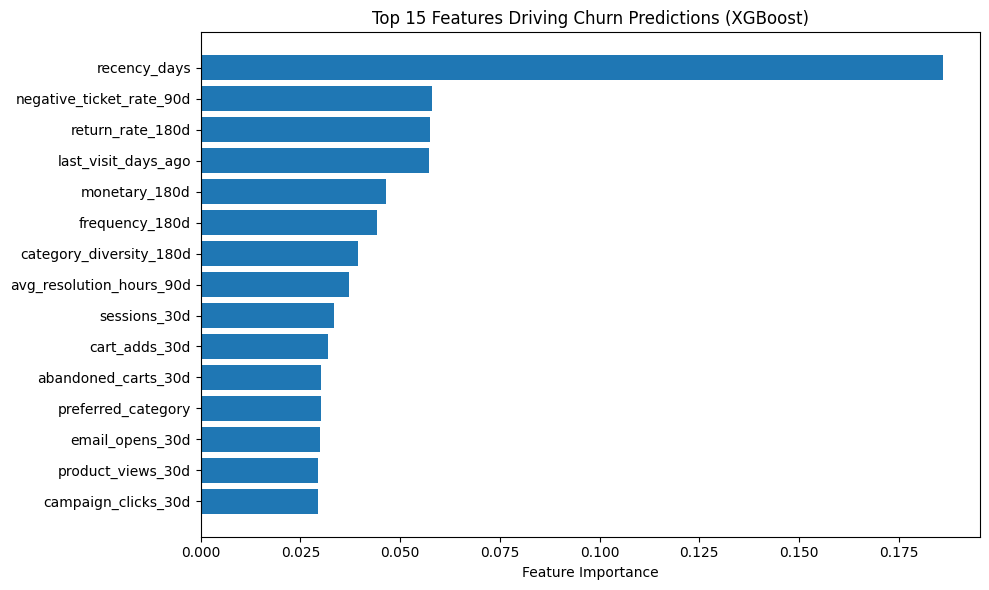


✓ Feature importance plot saved as 'feature_importance.png'


In [34]:
# Extract feature importance from XGBoost
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "=" * 60)
print("TOP 15 MOST IMPORTANT FEATURES FOR CHURN PREDICTION")
print("=" * 60)
print(feature_importance_df.head(15).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance_df.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('Top 15 Features Driving Churn Predictions (XGBoost)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Feature importance plot saved as 'feature_importance.png'")

## Section 10: Save Model & Performance Metrics

In [35]:
# Save the final model
joblib.dump(xgb_model, 'model.pkl')
print("✓ Model saved as 'model.pkl'")

# Save model artifacts
model_artifacts = {
    'model_type': 'XGBoost',
    'threshold': float(THRESHOLD),
    'feature_names': list(X_train.columns),
    'label_encoders': {col: list(label_encoders[col].classes_) for col in categorical_cols}
}
joblib.dump(model_artifacts, 'model_artifacts.pkl')
print("✓ Model artifacts saved as 'model_artifacts.pkl'")

# Compile metrics
metrics = {
    'model': 'XGBoost',
    'threshold': float(THRESHOLD),
    'test_accuracy': float(accuracy_score(y_test, y_test_pred_final)),
    'test_precision': float(precision_score(y_test, y_test_pred_final)),
    'test_recall': float(recall_score(y_test, y_test_pred_final)),
    'test_f1_score': float(f1_score(y_test, y_test_pred_final)),
    'test_roc_auc': float(roc_auc_score(y_test, y_test_proba_xgb)),
    'val_accuracy': float(accuracy_score(y_val, y_val_pred_final)),
    'val_precision': float(precision_score(y_val, y_val_pred_final)),
    'val_recall': float(recall_score(y_val, y_val_pred_final)),
    'val_f1_score': float(f1_score(y_val, y_val_pred_final)),
    'val_roc_auc': float(roc_auc_score(y_val, y_val_proba_xgb)),
    'n_features': len(X_train.columns),
    'n_train_samples': len(X_train),
    'n_val_samples': len(X_val),
    'n_test_samples': len(X_test),
    'churn_rate_train': float(y_train.mean()),
    'churn_rate_val': float(y_val.mean()),
    'churn_rate_test': float(y_test.mean()),
}

# Save metrics
with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("✓ Metrics saved as 'metrics.json'")

print("\n" + "=" * 60)
print("MODEL SUMMARY")
print("=" * 60)
for key, value in metrics.items():
    if isinstance(value, float):
        if key in ['threshold', 'churn_rate_train', 'churn_rate_val', 'churn_rate_test']:
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

✓ Model saved as 'model.pkl'
✓ Model artifacts saved as 'model_artifacts.pkl'
✓ Metrics saved as 'metrics.json'

MODEL SUMMARY
model: XGBoost
threshold: 0.5477
test_accuracy: 0.7857
test_precision: 0.7330
test_recall: 0.8988
test_f1_score: 0.8075
test_roc_auc: 0.8710
val_accuracy: 0.8125
val_precision: 0.7500
val_recall: 0.8571
val_f1_score: 0.8000
val_roc_auc: 0.8822
n_features: 25
n_train_samples: 1728
n_val_samples: 336
n_test_samples: 336
churn_rate_train: 0.4699
churn_rate_val: 0.4375
churn_rate_test: 0.5000


In [36]:
# 1. Feature importance
print(feature_importance_df.head(10).to_string(index=False))

# 2. Churn rates
print(f"Train churn: {y_train.mean()*100:.2f}%")
print(f"Val churn: {y_val.mean()*100:.2f}%")
print(f"Test churn: {y_test.mean()*100:.2f}%")

# 3. Error analysis summaries
print(false_negatives[['recency_days','sessions_30d','frequency_180d','monetary_180d']].describe())
print(false_positives[['recency_days','sessions_30d','frequency_180d','monetary_180d']].describe())

                 feature  importance
            recency_days    0.186073
negative_ticket_rate_90d    0.057979
        return_rate_180d    0.057556
     last_visit_days_ago    0.057351
           monetary_180d    0.046401
          frequency_180d    0.044237
 category_diversity_180d    0.039464
avg_resolution_hours_90d    0.037109
            sessions_30d    0.033376
           cart_adds_30d    0.031869
Train churn: 46.99%
Val churn: 43.75%
Test churn: 50.00%
       recency_days  sessions_30d  frequency_180d  monetary_180d
count     17.000000     17.000000       17.000000      17.000000
mean      45.882353      6.823529        2.294118    1684.715882
std       29.478557      4.733330        1.531531    1140.945622
min        9.000000      0.000000        1.000000     402.670000
25%       20.000000      3.000000        1.000000     715.360000
50%       42.000000      6.000000        2.000000    1358.990000
75%       64.000000     11.000000        3.000000    2204.460000
max      100.000